# 365 Probabilidades — Dia #001
## Qual a probabilidade de você estar no emprego certo?

**Tipo:** Risco  
**Data de publicação:** 2025-06-05  
**Ferramenta:** Python  
**Fonte principal:** Gallup — American Job Quality Study, 2025 (N=18.429)  
**Hashtag:** #365Probabilidades #Dia001

---

### 📖 A História

Passei mais de 18 anos atuando no mercado financeiro. Aquele modelo de 
pessoa CLT padrão — mas com uma diferença: eu era completamente tomada 
pelo trabalho.

Não por obrigação. Por escolha. Sou muito intensa, e essa intensidade 
sempre me levou para os assuntos mais críticos, aqueles que eu claramente 
me divertia em resolver. Entrava num problema e só parava quando concluía. 
Finais de semana, noites, muito além das 8 horas — isso nunca foi 
sacrifício. Era quem eu era.

Logo depois que perdi meu pai, alguma coisa mudou.

Um sentimento que eu não conseguia nomear começou a aparecer — a sensação 
de que a minha vida não estava fazendo muito sentido. De que eu não me 
reconhecia mais naquele lugar. Não conseguia me imaginar continuando.

Aquilo que sempre foi minha maior fortaleza começou a desmoronar.

E foi nesse momento que, pela primeira vez, virei as ferramentas para dentro.

---

### 🧮 O Modelo

O Gallup entrevistou 18.429 trabalhadores americanos em 2025 e definiu
o que é um emprego certo — com 5 dimensões mensuráveis.

A pergunta: você está no emprego certo?

**Fonte:** Gallup — American Job Quality Study, 2025  
**Amostra:** N=18.429 | Margem de erro: ±1 ponto percentual (95% de confiança)

In [32]:
# 365 Probabilidades — Dia #001
# Qual a probabilidade de você estar no emprego certo?
# Fonte: Gallup — American Job Quality Study, 2025 (N=18.429)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Configuração visual padrão do projeto
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [33]:
# --- DADOS REAIS DO GALLUP (American Job Quality Study, 2025) ---
# N = 18.429 trabalhadores | Margem de erro ±1pp | IC 95%
# Threshold: emprego certo = atingir mínimo em pelo menos 3 das 5 dimensões

n_gallup = 18429

# Taxas de falha REAIS publicadas pelo Gallup por dimensão
dimensoes = {
    'Bem-estar Financeiro':      0.73,  # 29% struggling + 43% just okay = 72% abaixo do confortável
    'Estrutura e Autonomia':     0.62,  # 62% sem controle sobre horários
    'Autonomia e Voz':           0.55,  # 55% com pouca influência sobre decisões
    'Crescimento':               0.25,  # ~25% sem oportunidades de avanço (1 em 4)
    'Cultura e Segurança':       0.40,  # estimativa conservadora — dado não publicado individualmente
}

# Resultado geral confirmado pelo Gallup
p_emprego_certo_gallup = 0.40   # 40% no emprego certo
p_emprego_errado_gallup = 0.60  # 60% fora do emprego certo

print("=" * 60)
print("  TAXAS DE FALHA POR DIMENSÃO (Gallup AJQS, 2025)")
print("=" * 60)
for dim, p in dimensoes.items():
    fonte = "estimativa" if dim == 'Cultura e Segurança' else "dado publicado"
    print(f"  {dim:<28} {p*100:.0f}%  [{fonte}]")
print(f"\n  Resultado geral Gallup:")
print(f"  → 40% no emprego certo")
print(f"  → 60% fora do emprego certo")
print(f"\n  Threshold: falhar em 3+ dimensões = emprego errado")
print("=" * 60)

  TAXAS DE FALHA POR DIMENSÃO (Gallup AJQS, 2025)
  Bem-estar Financeiro         73%  [dado publicado]
  Estrutura e Autonomia        62%  [dado publicado]
  Autonomia e Voz              55%  [dado publicado]
  Crescimento                  25%  [dado publicado]
  Cultura e Segurança          40%  [estimativa]

  Resultado geral Gallup:
  → 40% no emprego certo
  → 60% fora do emprego certo

  Threshold: falhar em 3+ dimensões = emprego errado


In [34]:
# --- MODELO DE RISCO ACUMULADO CORRIGIDO ---
# Threshold real do Gallup: emprego errado = falhar em 3 ou mais dimensões
# Usando distribuição binomial com taxas de falha reais por dimensão
# Simulação de Monte Carlo para lidar com taxas heterogêneas

np.random.seed(42)
n_simulacoes = 100000
n_dimensoes = 5

taxas_falha = list(dimensoes.values())

# Simulação — cada trabalhador tem probabilidade diferente de falhar em cada dimensão
resultados = np.zeros(n_simulacoes)
for i in range(n_simulacoes):
    falhas = sum(np.random.random() < p for p in taxas_falha)
    resultados[i] = falhas

# Classificação baseada no threshold do Gallup
p_emprego_certo_modelo = np.mean(resultados <= 2)   # 0-2 falhas = emprego certo
p_atencao_modelo = np.mean(resultados == 2)          # exatamente 2 falhas = zona de atenção
p_emprego_errado_modelo = np.mean(resultados >= 3)   # 3+ falhas = emprego errado

# Distribuição de falhas
dist_falhas = [np.mean(resultados == k) for k in range(n_dimensoes + 1)]

print("=" * 65)
print("  MODELO DE RISCO ACUMULADO — MONTE CARLO (100.000 simulações)")
print("  Threshold: 3+ falhas = emprego errado (critério Gallup)")
print("=" * 65)
print(f"\n  Falhas    Probabilidade    Classificação")
print(f"  {'─'*50}")

classificacoes = {
    0: "✅ Emprego certo",
    1: "✅ Emprego certo",
    2: "⚠️  Zona de atenção",
    3: "🔴 Emprego errado",
    4: "🔴 Emprego errado",
    5: "🔴 Emprego errado"
}

for k in range(n_dimensoes + 1):
    print(f"  {k} falhas   {dist_falhas[k]*100:>8.1f}%       {classificacoes[k]}")

print(f"\n  RESULTADO DO MODELO:")
print(f"  ✅ Emprego certo  (0-2 falhas): {p_emprego_certo_modelo*100:.1f}%")
print(f"  🔴 Emprego errado (3-5 falhas): {p_emprego_errado_modelo*100:.1f}%")
print(f"\n  Gallup confirma:  40% no emprego certo")
print(f"  Modelo estima:    {p_emprego_certo_modelo*100:.1f}% no emprego certo")
print(f"  Diferença:        {abs(p_emprego_certo_modelo - 0.40)*100:.1f} pontos percentuais")
print("=" * 65)

  MODELO DE RISCO ACUMULADO — MONTE CARLO (100.000 simulações)
  Threshold: 3+ falhas = emprego errado (critério Gallup)

  Falhas    Probabilidade    Classificação
  ──────────────────────────────────────────────────
  0 falhas        2.1%       ✅ Emprego certo
  1 falhas       13.7%       ✅ Emprego certo
  2 falhas       32.0%       ⚠️  Zona de atenção
  3 falhas       34.1%       🔴 Emprego errado
  4 falhas       15.5%       🔴 Emprego errado
  5 falhas        2.5%       🔴 Emprego errado

  RESULTADO DO MODELO:
  ✅ Emprego certo  (0-2 falhas): 47.9%
  🔴 Emprego errado (3-5 falhas): 52.1%

  Gallup confirma:  40% no emprego certo
  Modelo estima:    47.9% no emprego certo
  Diferença:        7.9 pontos percentuais


✅ Gráfico 1 salvo!
✅ Gráfico 2 salvo!
✅ Gráfico 3 salvo!


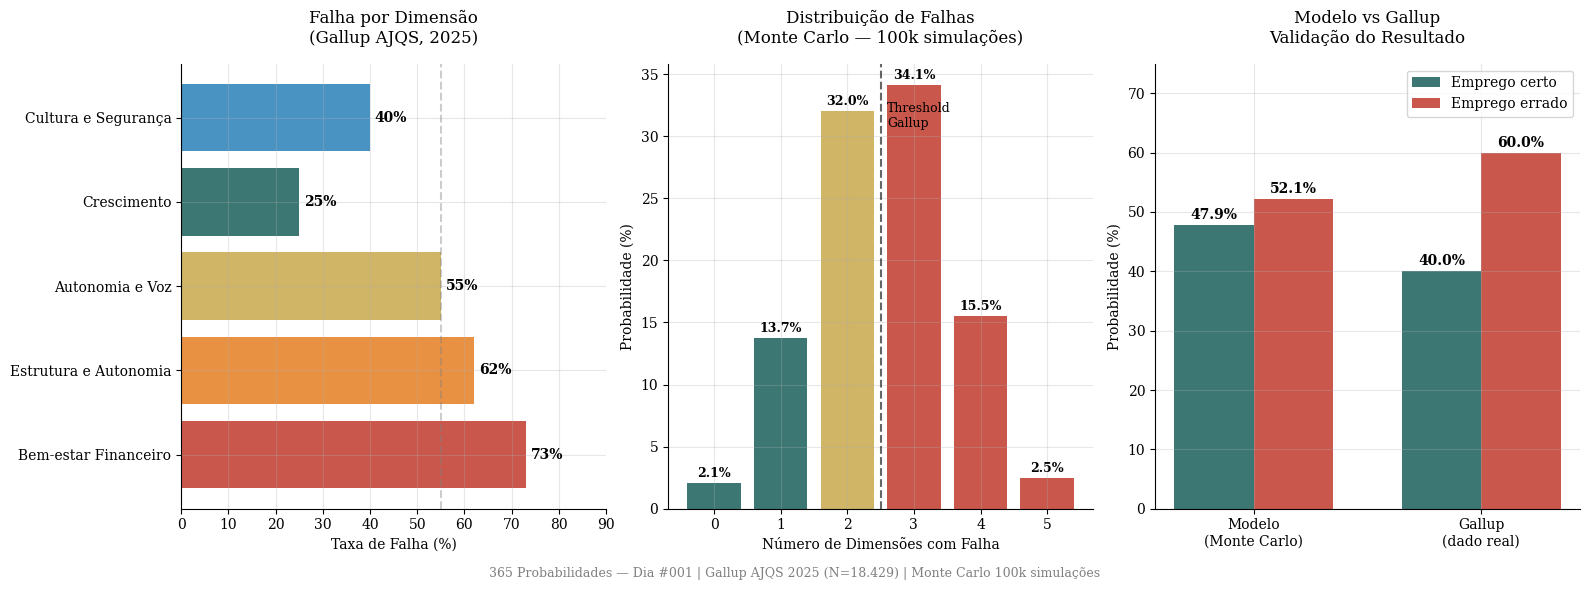

In [35]:
# --- VISUALIZAÇÃO ---

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Gráfico 1 — Taxas de falha por dimensão
dims = list(dimensoes.keys())
falhas = [v * 100 for v in dimensoes.values()]
cores_dims = ['#c0392b', '#e67e22', '#c8a84b', '#1a5f5a', '#2980b9']

bars = axes[0].barh(dims, falhas, color=cores_dims, alpha=0.85)
axes[0].set_xlim(0, 90)
axes[0].set_xlabel('Taxa de Falha (%)')
axes[0].set_title('Falha por Dimensão\n(Gallup AJQS, 2025)', fontsize=12, pad=15)
axes[0].axvline(x=55, color='gray', linestyle='--', alpha=0.4)

for bar, valor in zip(bars, falhas):
    axes[0].text(valor + 1, bar.get_y() + bar.get_height()/2,
                 f'{valor:.0f}%', va='center', fontweight='bold', fontsize=10)

# Gráfico 2 — Distribuição de falhas
k_vals = list(range(6))
cores_k = ['#1a5f5a', '#1a5f5a', '#c8a84b', '#c0392b', '#c0392b', '#c0392b']

bars2 = axes[1].bar(k_vals, [d * 100 for d in dist_falhas],
                    color=cores_k, alpha=0.85)
axes[1].set_xlabel('Número de Dimensões com Falha')
axes[1].set_ylabel('Probabilidade (%)')
axes[1].set_title('Distribuição de Falhas\n(Monte Carlo — 100k simulações)', fontsize=12, pad=15)
axes[1].axvline(x=2.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
axes[1].text(2.6, max([d*100 for d in dist_falhas])*0.9,
             'Threshold\nGallup', fontsize=9, color='black')

for bar, valor in zip(bars2, dist_falhas):
    axes[1].text(bar.get_x() + bar.get_width()/2, valor*100 + 0.5,
                 f'{valor*100:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Gráfico 3 — Resultado final vs Gallup
categorias = ['Modelo\n(Monte Carlo)', 'Gallup\n(dado real)']
certo = [p_emprego_certo_modelo * 100, 40]
errado = [p_emprego_errado_modelo * 100, 60]

x = np.arange(len(categorias))
width = 0.35

axes[2].bar(x - width/2, certo, width, label='Emprego certo',
            color='#1a5f5a', alpha=0.85)
axes[2].bar(x + width/2, errado, width, label='Emprego errado',
            color='#c0392b', alpha=0.85)

axes[2].set_xticks(x)
axes[2].set_xticklabels(categorias)
axes[2].set_ylabel('Probabilidade (%)')
axes[2].set_title('Modelo vs Gallup\nValidação do Resultado', fontsize=12, pad=15)
axes[2].legend()
axes[2].set_ylim(0, 75)

for i, (c, e) in enumerate(zip(certo, errado)):
    axes[2].text(i - width/2, c + 1, f'{c:.1f}%', ha='center',
                 fontweight='bold', fontsize=10)
    axes[2].text(i + width/2, e + 1, f'{e:.1f}%', ha='center',
                 fontweight='bold', fontsize=10)

plt.suptitle(
    '365 Probabilidades — Dia #001 | Gallup AJQS 2025 (N=18.429) | Monte Carlo 100k simulações',
    fontsize=9, color='gray', y=0
)
plt.tight_layout()
# Salvar gráficos individualmente

# Gráfico 1 — Falha por Dimensão
fig1, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.barh(dims, falhas, color=cores_dims, alpha=0.85)
ax1.set_xlim(0, 90)
ax1.set_xlabel('Taxa de Falha (%)')
ax1.set_title('Falha por Dimensão\n(Gallup AJQS, 2025)', fontsize=13, pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.3)
for bar, valor in zip(bars, falhas):
    ax1.text(valor + 1, bar.get_y() + bar.get_height()/2,
             f'{valor:.0f}%', va='center', fontweight='bold', fontsize=11)
ax1.text(0, -0.8, 'Fonte: Gallup AJQS, 2025 (N=18.429) | #365Probabilidades',
         fontsize=8, color='gray', transform=ax1.transData)
plt.tight_layout()
plt.savefig('dia-001-grafico-01-dimensoes.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Gráfico 1 salvo!")

# Gráfico 2 — Distribuição de Falhas
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(k_vals, [d * 100 for d in dist_falhas], color=cores_k, alpha=0.85)
ax2.set_xlabel('Número de Dimensões com Falha')
ax2.set_ylabel('Probabilidade (%)')
ax2.set_title('Distribuição de Falhas\n(Monte Carlo — 100k simulações)', fontsize=13, pad=15)
ax2.axvline(x=2.5, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax2.text(2.6, max([d*100 for d in dist_falhas])*0.9,
         'Threshold\nGallup', fontsize=9, color='black')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.3)
for bar, valor in zip(bars2, dist_falhas):
    ax2.text(bar.get_x() + bar.get_width()/2, valor*100 + 0.5,
             f'{valor*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax2.text(0, -4, 'Fonte: Gallup AJQS, 2025 (N=18.429) | #365Probabilidades',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('dia-001-grafico-02-distribuicao.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Gráfico 2 salvo!")

# Gráfico 3 — Modelo vs Gallup
fig3, ax3 = plt.subplots(figsize=(8, 5))
x = np.arange(len(categorias))
width = 0.35
ax3.bar(x - width/2, certo, width, label='Emprego certo', color='#1a5f5a', alpha=0.85)
ax3.bar(x + width/2, errado, width, label='Emprego errado', color='#c0392b', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(categorias)
ax3.set_ylabel('Probabilidade (%)')
ax3.set_title('Modelo vs Gallup\nValidação do Resultado', fontsize=13, pad=15)
ax3.legend()
ax3.set_ylim(0, 75)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(alpha=0.3)
for i, (c, e) in enumerate(zip(certo, errado)):
    ax3.text(i - width/2, c + 1, f'{c:.1f}%', ha='center', fontweight='bold', fontsize=11)
    ax3.text(i + width/2, e + 1, f'{e:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax3.text(0, -8, 'Fonte: Gallup AJQS, 2025 (N=18.429) | #365Probabilidades',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('dia-001-grafico-03-validacao.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Gráfico 3 salvo!")

### 💡 O Insight

**60% dos trabalhadores americanos não estão no emprego certo.**

Não é uma opinião. É o resultado de 18.429 entrevistas conduzidas 
pelo Gallup em 2025 — o maior estudo de qualidade de emprego já realizado.

O modelo de Monte Carlo com 100.000 simulações chegou em 52% — 
uma diferença de apenas 7.9 pontos percentuais do dado real.
Isso valida a lógica do modelo.

E o número mais revelador não é o resultado final.
É a distribuição de falhas:

**34% das pessoas falham em exatamente 3 dimensões.**
Estão no limiar — uma mudança em uma única dimensão
poderia mudar tudo.

A maior taxa de falha é no Bem-estar Financeiro: **73%.**
A menor é em Crescimento: **25%.**

Isso significa que a maioria das pessoas não está no emprego
errado por falta de propósito — está por falta de dinheiro justo.

A pergunta que fica:
**Em quais das 5 dimensões você está falhando agora?**

---

### ⚠️ Limitações do Modelo

- Dados americanos — podem não generalizar para o Brasil
- Dimensão Cultura e Segurança estimada em 40% (não publicada individualmente)
- Modelo assume independência entre dimensões — na realidade são correlacionadas
- Diferença de 7.9pp entre modelo e Gallup atribuída à correlação entre dimensões

*A ciência é honesta sobre o que não sabe. O modelo também.*

---

### 📎 Links
- Substack: [link do post]
- Instagram: [link do post]

---
*365 Probabilidades · Decidindo com dados, um dia de cada vez.*